### 라이브러리 임포트

In [1]:
# gensim 및 의존성 설치
!pip install gensim==4.3.2
!pip install scipy==1.12.0 numpy==1.26.3  # 의존성 버전 맞추기

# 설치 후 런타임 재시작 필요 → 재시작 후 아래 import 실행
import importlib, gensim
print(f"gensim 버전: {gensim.__version__}")

gensim 버전: 4.3.2


In [2]:
import os
import requests

real_dir = os.getenv("HOME") + '/data'

# ── 폴더 생성 ─────────────────────────────────────────────────
os.makedirs(real_dir, exist_ok=True)
print("폴더 생성 완료:", real_dir)

# ── 다운로드 ──────────────────────────────────────────────────
urls = {
    'ratings_train.txt': 'https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt',
    'ratings_test.txt' : 'https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt'
}

for filename, url in urls.items():
    filepath = os.path.join(real_dir, filename)
    print(f"\n{filename} 다운로드 중...")
    r = requests.get(url)
    with open(filepath, 'wb') as f:
        f.write(r.content)
    print(f"완료! ({os.path.getsize(filepath):,} bytes)")

# ── 최종 확인 ─────────────────────────────────────────────────
print("\n저장된 파일 목록:")
for f in os.listdir(real_dir):
    print(f"  {f}")

폴더 생성 완료: /home/jovyan/data

ratings_train.txt 다운로드 중...
완료! (14,628,807 bytes)

ratings_test.txt 다운로드 중...
완료! (4,893,335 bytes)

저장된 파일 목록:
  ratings_train.txt
  ratings_test.txt


In [3]:
import pandas as pd
import numpy as np
import os
from konlpy.tag import Mecab
from collections import Counter

# ── 데이터 로드 ──────────────────────────────────────────────
train_data = pd.read_table(os.getenv("HOME") + '/work/sentiment_classification/data/ratings_train.txt')
test_data  = pd.read_table(os.getenv("HOME") + '/work/sentiment_classification/data/ratings_test.txt')

# ── 전처리 설정 ──────────────────────────────────────────────
tokenizer = Mecab()
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

# ── load_data 함수 정의 ──────────────────────────────────────
def load_data(train_data, test_data, num_words=10000):
    train_data.drop_duplicates(subset=['document'], inplace=True)
    train_data = train_data.dropna(how='any')
    test_data.drop_duplicates(subset=['document'], inplace=True)
    test_data = test_data.dropna(how='any')

    X_train = []
    for sentence in train_data['document']:
        temp_X = tokenizer.morphs(sentence)
        temp_X = [word for word in temp_X if word not in stopwords]
        X_train.append(temp_X)

    X_test = []
    for sentence in test_data['document']:
        temp_X = tokenizer.morphs(sentence)
        temp_X = [word for word in temp_X if word not in stopwords]
        X_test.append(temp_X)

    words = np.concatenate(X_train).tolist()
    counter = Counter(words)
    counter = counter.most_common(num_words - 4)
    vocab = ['<PAD>', '<BOS>', '<UNK>', '<EOS>'] + [key for key, _ in counter]
    word_to_index = {word: index for index, word in enumerate(vocab)}

    def wordlist_to_indexlist(wordlist):
        return [word_to_index[word] if word in word_to_index else word_to_index['<UNK>'] for word in wordlist]

    X_train = list(map(wordlist_to_indexlist, X_train))
    X_test  = list(map(wordlist_to_indexlist, X_test))

    return X_train, np.array(list(train_data['label'])), X_test, np.array(list(test_data['label'])), word_to_index

# ── 실행 ─────────────────────────────────────────────────────
X_train, y_train, X_test, y_test, word_to_index = load_data(train_data, test_data)
index_to_word = {index: word for word, index in word_to_index.items()}

print(f"훈련 데이터: {len(X_train)}개")
print(f"테스트 데이터: {len(X_test)}개")
print(f"어휘 크기: {len(word_to_index)}개")

훈련 데이터: 146182개
테스트 데이터: 49157개
어휘 크기: 10000개


### 데이터 로드

In [4]:
# load_data()는 기존 코드에서 이미 실행된 상태
# X_train: 숫자 인덱스로 인코딩된 훈련 문장 리스트 (예: [[1,5,23,...], ...])
# y_train: 감성 레이블 배열 (0=부정, 1=긍정)
# word_to_index: 단어 → 인덱스 딕셔너리 (예: {'나는': 1, '영화': 2, ...})

print(f"훈련 데이터: {len(X_train)}개")
print(f"테스트 데이터: {len(X_test)}개")
print(f"어휘 크기: {len(word_to_index)}개")

훈련 데이터: 146182개
테스트 데이터: 49157개
어휘 크기: 10000개


### 데이터셋과 데이터로더 정의

In [7]:
from torch.utils.data import Dataset, DataLoader
class SentimentDataset(Dataset):
    """
    PyTorch Dataset 클래스.
    DataLoader가 배치 단위로 데이터를 꺼낼 수 있도록 __len__, __getitem__ 구현.
    """
    def __init__(self, X, y, max_len=100):
        self.X = X            # 인코딩된 문장 리스트
        self.y = y            # 레이블 배열
        self.max_len = max_len  # 문장 최대 길이 (초과 시 자름)

    def __len__(self):
        # 전체 샘플 수 반환 (DataLoader가 배치 크기 계산에 사용)
        return len(self.X)

    def __getitem__(self, idx):
        # max_len 초과 시 앞에서부터 자르기
        seq = self.X[idx][:self.max_len]
        # 리스트 → PyTorch 텐서로 변환
        return (
            torch.tensor(seq, dtype=torch.long),          # 문장 (정수 인덱스)
            torch.tensor(self.y[idx], dtype=torch.float)  # 레이블 (0.0 또는 1.0)
        )


def collate_fn(batch):
    """
    배치 내 문장 길이가 제각각이므로 패딩으로 길이를 통일하는 함수.
    DataLoader의 collate_fn 인자로 전달됨.
    
    예) 배치 = [[1,5,3], [1,2], [4,6,7,8]]
        → [[1,5,3,0], [1,2,0,0], [4,6,7,8]]  (padding_value=0으로 채움)
    """
    seqs, labels = zip(*batch)  # 문장들과 레이블들을 분리
    # batch_first=True: 출력 shape = (배치크기, 최대길이)
    # padding_value=0: <PAD> 토큰 인덱스와 동일하게 0으로 패딩
    padded = pad_sequence(seqs, batch_first=True, padding_value=0)
    return padded, torch.stack(labels)


MAX_LEN = 100    # 100 형태소 초과 문장은 앞부분만 사용
BATCH_SIZE = 64  # 한 번에 64개 샘플씩 학습

train_dataset = SentimentDataset(X_train, y_train, MAX_LEN)
test_dataset  = SentimentDataset(X_test,  y_test,  MAX_LEN)

# shuffle=True: 매 에폭마다 순서를 섞어 과적합 방지
# collate_fn: 위에서 정의한 패딩 함수 연결
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
print("DataLoader 준비 완료")

DataLoader 준비 완료


### 공통학습/평가함

In [11]:
def train_model(model, loader, optimizer, criterion, epochs=5):
    """
    모델 학습 함수. 모든 모델(LSTM, GRU, Word2Vec+LSTM)에서 공통으로 사용.
    
    Args:
        model    : 학습할 PyTorch 모델
        loader   : 훈련용 DataLoader
        optimizer: 옵티마이저 (Adam 등)
        criterion: 손실 함수 (BCEWithLogitsLoss)
        epochs   : 반복 학습 횟수
    Returns:
        history  : 에폭별 loss, accuracy 기록 리스트
    """
    model.train()  # 드롭아웃, 배치정규화 등을 훈련 모드로 전환
    history = []

    for epoch in range(epochs):
        total_loss, correct, total = 0, 0, 0

        for X_batch, y_batch in loader:
            # GPU로 데이터 이동 (CPU면 그대로)
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()          # 이전 배치의 기울기 초기화 (누적 방지)
            output = model(X_batch).squeeze(1)  # 모델 예측 (shape: [배치크기])
            loss = criterion(output, y_batch)   # 손실 계산

            loss.backward()    # 역전파: 각 파라미터의 기울기 계산
            optimizer.step()   # 파라미터 업데이트 (기울기 방향으로 이동)

            total_loss += loss.item()

            # sigmoid로 확률 변환 후 0.5 기준으로 0/1 분류
            preds = (torch.sigmoid(output) >= 0.5).float()
            correct += (preds == y_batch).sum().item()
            total += len(y_batch)

        acc = correct / total
        history.append({'epoch': epoch+1, 'loss': total_loss/len(loader), 'acc': acc})
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(loader):.4f} | Acc: {acc:.4f}")

    return history


def evaluate_model(model, loader):
    """
    테스트 데이터로 최종 정확도 평가.
    torch.no_grad(): 평가 시에는 기울기 계산 불필요 → 메모리 절약, 속도 향상
    """
    model.eval()  # 드롭아웃 비활성화, 배치정규화 고정
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            output = model(X_batch).squeeze(1)
            preds = (torch.sigmoid(output) >= 0.5).float().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    return accuracy_score(all_labels, all_preds)

### Model 1 : Bi-LSTM

In [15]:
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score
from torch.nn.utils.rnn import pad_sequence
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 장치: {device}")
class LSTMClassifier(nn.Module):
    """
    양방향 LSTM 기반 감성 분류 모델.
    
    구조: Embedding → Dropout → Bi-LSTM → FC → 출력(로짓)
    
    양방향(Bidirectional): 문장을 앞→뒤, 뒤→앞 두 방향으로 읽어
    문맥을 더 풍부하게 포착. hidden_dim이 두 배로 늘어남.
    """
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256, n_layers=2, dropout=0.3):
        super().__init__()

        # 임베딩 레이어: 단어 인덱스 → 밀집 벡터
        # padding_idx=0: <PAD> 토큰은 항상 0벡터 유지 (기울기도 0)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # LSTM 레이어
        # bidirectional=True: 순방향 + 역방향 hidden을 concat → 출력 dim = hidden_dim*2
        # n_layers=2: LSTM 2층 쌓기 (더 복잡한 패턴 학습)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, n_layers,
            batch_first=True,
            dropout=dropout,       # LSTM 레이어 사이 드롭아웃
            bidirectional=True
        )

        # 최종 분류기: 양방향이라 hidden_dim*2, 이진분류라 출력 1개
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)  # 과적합 방지용 드롭아웃

    def forward(self, x):
        # x shape: (배치크기, 시퀀스길이)
        emb = self.dropout(self.embedding(x))
        # emb shape: (배치크기, 시퀀스길이, embed_dim)

        _, (hidden, _) = self.lstm(emb)
        # hidden shape: (n_layers*2, 배치크기, hidden_dim)
        # hidden[-2]: 순방향 마지막 레이어, hidden[-1]: 역방향 마지막 레이어
        out = torch.cat([hidden[-2], hidden[-1]], dim=1)
        # out shape: (배치크기, hidden_dim*2)

        return self.fc(self.dropout(out))
        # 반환 shape: (배치크기, 1) — BCEWithLogitsLoss에 넣을 로짓값


VOCAB_SIZE = len(word_to_index)

model1 = LSTMClassifier(VOCAB_SIZE).to(device)
optimizer1 = torch.optim.Adam(model1.parameters(), lr=1e-3)

# BCEWithLogitsLoss = Sigmoid + BCELoss 결합
# 수치적으로 더 안정적 (별도로 sigmoid 호출 불필요)
criterion = nn.BCEWithLogitsLoss()

print("=== Model 1: Bi-LSTM ===")
history1 = train_model(model1, train_loader, optimizer1, criterion, epochs=5)
acc1 = evaluate_model(model1, test_loader)
print(f"\n[Model 1] 테스트 정확도: {acc1:.4f} ({acc1*100:.2f}%)")

사용 장치: cuda
=== Model 1: Bi-LSTM ===
Epoch 1/5 | Loss: 0.4436 | Acc: 0.7878
Epoch 2/5 | Loss: 0.3375 | Acc: 0.8502
Epoch 3/5 | Loss: 0.2983 | Acc: 0.8713
Epoch 4/5 | Loss: 0.2714 | Acc: 0.8850
Epoch 5/5 | Loss: 0.2527 | Acc: 0.8938

[Model 1] 테스트 정확도: 0.8755 (87.55%)


### Model2 : Bi-GRU

In [16]:
class GRUClassifier(nn.Module):
    """
    양방향 GRU 기반 감성 분류 모델.
    
    GRU vs LSTM:
    - GRU: gate 2개 (reset, update) → 파라미터 적음, 학습 빠름
    - LSTM: gate 3개 (input, forget, output) + cell state → 장기 의존성에 강함
    - 짧은 리뷰 데이터에서는 GRU가 LSTM과 비슷하거나 더 좋을 수 있음
    """
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256, n_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # GRU는 cell state 없이 hidden state만 반환
        self.gru = nn.GRU(
            embed_dim, hidden_dim, n_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))

        # GRU는 (output, hidden)만 반환 (LSTM처럼 cell state 없음)
        _, hidden = self.gru(emb)
        # hidden shape: (n_layers*2, 배치크기, hidden_dim)
        out = torch.cat([hidden[-2], hidden[-1]], dim=1)

        return self.fc(self.dropout(out))


model2 = GRUClassifier(VOCAB_SIZE).to(device)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=1e-3)

print("=== Model 2: Bi-GRU ===")
history2 = train_model(model2, train_loader, optimizer2, criterion, epochs=5)
acc2 = evaluate_model(model2, test_loader)
print(f"\n[Model 2] 테스트 정확도: {acc2:.4f} ({acc2*100:.2f}%)")

=== Model 2: Bi-GRU ===
Epoch 1/5 | Loss: 0.4324 | Acc: 0.7916
Epoch 2/5 | Loss: 0.3328 | Acc: 0.8533
Epoch 3/5 | Loss: 0.2984 | Acc: 0.8707
Epoch 4/5 | Loss: 0.2729 | Acc: 0.8838
Epoch 5/5 | Loss: 0.2532 | Acc: 0.8927

[Model 2] 테스트 정확도: 0.8736 (87.36%)


### Word2Vec 자체학습 및 유사단어 분석

In [18]:
# 7-1. Word2Vec 학습용 토큰 코퍼스 구축 
from gensim.models import Word2Vec
tokenizer = Mecab()
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

train_data_raw = pd.read_table(os.getenv("HOME") + '/work/sentiment_classification/data/ratings_train.txt')
train_data_raw.drop_duplicates(subset=['document'], inplace=True)
train_data_raw.dropna(inplace=True)

token_corpus = []
for sent in train_data_raw['document']:
    tokens = tokenizer.morphs(sent)                          # 형태소 단위 토큰화
    tokens = [t for t in tokens if t not in stopwords]      # 불용어 제거
    token_corpus.append(tokens)
# token_corpus: [['영화', '정말', '재미'], ['최악', '이다'], ...]


# 7-2. Word2Vec 모델 학습
w2v_model = Word2Vec(
    sentences=token_corpus,   # 학습 데이터: 토큰 리스트의 리스트
    vector_size=128,          # 각 단어를 128차원 벡터로 표현
    window=5,                 # 주변 단어 범위: 앞뒤 5개 단어를 문맥으로 사용
    min_count=3,              # 3번 미만 등장 단어는 어휘에서 제외 (노이즈 제거)
    workers=4,                # 병렬 처리 스레드 수
    epochs=10,                # 전체 코퍼스를 10번 반복 학습
    sg=1                      # 1=Skip-gram (중심단어→주변단어 예측), 0=CBOW (반대)
                              # Skip-gram이 희소 단어에 더 강함
)
print("Word2Vec 학습 완료!")
print(f"어휘 크기: {len(w2v_model.wv)}")


# 7-3. 자체 학습 임베딩 유사 단어 분석 
# most_similar(): 코사인 유사도 기준 가장 가까운 단어 반환
# 임베딩이 의미적 관계를 제대로 학습했는지 확인하는 용도
print("\n=== 자체학습 Word2Vec 유사 단어 분석 ===")
test_words = ['재미', '감동', '최악', '배우', '연기']
for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f"\n[{word}]와 유사한 단어:")
        for w, score in similar:
            print(f"  {w}: {score:.4f}")  # score: 코사인 유사도 (1에 가까울수록 유사)

Word2Vec 학습 완료!
어휘 크기: 22657

=== 자체학습 Word2Vec 유사 단어 분석 ===

[재미]와 유사한 단어:
  제미: 0.6443
  짜여: 0.6146
  두서: 0.6059
  스릴: 0.6059
  ....................: 0.5942

[감동]와 유사한 단어:
  교훈: 0.6394
  강동: 0.6287
  깨달음: 0.6057
  브라보: 0.6028
  물결: 0.5891

[최악]와 유사한 단어:
  워스트: 0.6508
  등극: 0.6267
  쓰레기: 0.6224
  형편: 0.6151
  여지껏: 0.6114

[배우]와 유사한 단어:
  연기자: 0.7141
  여배우: 0.6924
  연기파: 0.6498
  명배우: 0.6431
  안성기: 0.6283

[연기]와 유사한 단어:
  연기력: 0.8408
  케미: 0.6604
  발연기: 0.6584
  연기파: 0.6521
  김민준: 0.6497


### 사전학습 임베딩 로드 및 비교 분석

In [22]:
# fastText 한국어 벡터 다운로드 (약 2.5GB, 시간이 오래 걸림)
!wget -O /tmp/cc.ko.300.vec.gz https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.ko.300.vec.gz

# 압축 해제
!gunzip /tmp/cc.ko.300.vec.gz

# 파일 확인
!ls -lh /tmp/cc.ko.300.vec

--2026-04-13 14:24:09--  https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.ko.300.vec.gz
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.169.121.57, 3.169.121.110, 3.169.121.107, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.169.121.57|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1267506825 (1.2G) [binary/octet-stream]
Saving to: ‘/tmp/cc.ko.300.vec.gz’

/tmp/cc.ko.300.vec. 100%[===================>]   1.18G  38.8MB/s    in 33s     

2026-04-13 14:24:42 (36.9 MB/s) - ‘/tmp/cc.ko.300.vec.gz’ saved [1267506825/1267506825]

-rw-r--r-- 1 jovyan users 4.3G Jan 18  2019 /tmp/cc.ko.300.vec


In [21]:
# 사전학습 임베딩: 수억 개의 문서로 학습된 임베딩
# → 자체 학습보다 훨씬 넓은 어휘와 풍부한 의미 관계를 가짐
# 옵션 A: fastText 한국어 다운로드 (약 2.5GB, 처음 한 번만 실행)
# !wget -O /tmp/cc.ko.300.vec.gz https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.ko.300.vec.gz
# !gunzip /tmp/cc.ko.300.vec.gz

PRETRAINED_PATH = '/tmp/cc.ko.300.vec'  # 경로를 실제 파일 위치로 수정

try:
    # limit=200000: 상위 20만 개 단어만 로드 (전체 로드 시 메모리 부족 가능)
    pretrained_wv = KeyedVectors.load_word2vec_format(
        PRETRAINED_PATH, binary=False, limit=200000
    )
    print(f"사전학습 임베딩 로드 완료: {len(pretrained_wv)} 단어")

    # ── 자체학습 vs 사전학습 유사 단어 비교 ──
    # 같은 단어에 대해 두 임베딩이 어떤 단어를 유사하다고 보는지 비교
    # → 코퍼스 크기/도메인 차이에 따른 임베딩 품질 차이를 확인
    print("\n=== 자체학습 vs 사전학습 유사 단어 비교 ===")
    for word in ['재미', '감동', '최악']:
        print(f"\n--- [{word}] ---")
        if word in w2v_model.wv:
            my_sim = [w for w, _ in w2v_model.wv.most_similar(word, topn=5)]
            print(f"  자체학습 : {my_sim}")
        if word in pretrained_wv:
            pre_sim = [w for w, _ in pretrained_wv.most_similar(word, topn=5)]
            print(f"  사전학습 : {pre_sim}")

    HAS_PRETRAINED = True

except Exception as e:
    print(f"사전학습 임베딩 로드 실패: {e}")
    print("자체학습 Word2Vec만 사용합니다.")
    HAS_PRETRAINED = False

사전학습 임베딩 로드 실패: [Errno 2] No such file or directory: '/tmp/cc.ko.300.vec'
자체학습 Word2Vec만 사용합니다.


### Model3 : Word2Vec + Bi=LSTM

In [23]:
# 9-1. Word2Vec 가중치 → PyTorch 임베딩 행렬 변환 
EMBED_DIM = 128  # Word2Vec의 vector_size와 반드시 일치해야 함

# 임베딩 행렬: shape = (어휘크기, 임베딩차원)
# 모델 어휘(word_to_index)의 각 단어 인덱스 위치에 Word2Vec 벡터를 채움
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))

found, notfound = 0, 0
for word, idx in word_to_index.items():
    if word in w2v_model.wv:
        # Word2Vec이 학습한 벡터를 그대로 사용
        embedding_matrix[idx] = w2v_model.wv[word]
        found += 1
    else:
        # Word2Vec 어휘에 없는 단어: 작은 랜덤값으로 초기화
        # (0으로 두면 학습이 안 됨, 너무 크면 다른 벡터와 충돌)
        embedding_matrix[idx] = np.random.normal(0, 0.1, EMBED_DIM)
        notfound += 1

print(f"임베딩 행렬: found={found}, not_found={notfound} ({found/VOCAB_SIZE*100:.1f}% 커버)")


# 9-2. Word2Vec 임베딩 적용 LSTM 모델 정의 
class Word2VecLSTM(nn.Module):
    """
    사전학습(Word2Vec) 임베딩을 초기값으로 사용하는 Bi-LSTM.
    
    전이학습 전략:
    - freeze=False (기본): 임베딩을 초기값으로만 쓰고 학습 중 계속 업데이트
      → 감성분석 도메인에 맞게 미세조정(fine-tuning) 됨
    - freeze=True: 임베딩 고정, LSTM/FC만 학습
      → 데이터가 적을 때 유용 (임베딩 품질 보존)
    """
    def __init__(self, vocab_size, embed_dim, embedding_matrix,
                 hidden_dim=256, n_layers=2, dropout=0.3, freeze=False):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # 미리 만든 임베딩 행렬을 가중치로 직접 주입
        self.embedding.weight = nn.Parameter(torch.FloatTensor(embedding_matrix))

        # freeze=True이면 역전파 시 임베딩 가중치를 업데이트하지 않음
        self.embedding.weight.requires_grad = not freeze

        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, n_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(emb)
        out = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.fc(self.dropout(out))


# freeze=False: Word2Vec 벡터를 시작점으로 fine-tuning
model3 = Word2VecLSTM(VOCAB_SIZE, EMBED_DIM, embedding_matrix, freeze=False).to(device)

# lr을 Model1/2보다 낮게 설정: 이미 좋은 임베딩을 너무 많이 바꾸지 않기 위해
optimizer3 = torch.optim.Adam(model3.parameters(), lr=5e-4)

# 성능이 개선되지 않으면 lr을 0.5배로 줄임 (patience=1 에폭 동안 개선 없으면 작동)
scheduler3 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer3, patience=1, factor=0.5
)

print("=== Model 3: Word2Vec + Bi-LSTM ===")
history3 = train_model(model3, train_loader, optimizer3, criterion, epochs=7)
acc3 = evaluate_model(model3, test_loader)
print(f"\n[Model 3] 테스트 정확도: {acc3:.4f} ({acc3*100:.2f}%)")

임베딩 행렬: found=9996, not_found=4 (100.0% 커버)
=== Model 3: Word2Vec + Bi-LSTM ===
Epoch 1/7 | Loss: 0.3795 | Acc: 0.8298
Epoch 2/7 | Loss: 0.3136 | Acc: 0.8635
Epoch 3/7 | Loss: 0.2842 | Acc: 0.8796
Epoch 4/7 | Loss: 0.2640 | Acc: 0.8885
Epoch 5/7 | Loss: 0.2478 | Acc: 0.8970
Epoch 6/7 | Loss: 0.2318 | Acc: 0.9039
Epoch 7/7 | Loss: 0.2171 | Acc: 0.9110

[Model 3] 테스트 정확도: 0.8774 (87.74%)


### 최종 성능비교 시각

/tmp/ipykernel_18712/3170724539.py:38: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) URW Gothic.
  plt.tight_layout()
/tmp/ipykernel_18712/3170724539.py:38: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) URW Gothic.
  plt.tight_layout()
/tmp/ipykernel_18712/3170724539.py:38: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) URW Gothic.
  plt.tight_layout()
/tmp/ipykernel_18712/3170724539.py:38: UserWarning: Glyph 45348 (\N{HANGUL SYLLABLE NE}) missing from font(s) URW Gothic.
  plt.tight_layout()
/tmp/ipykernel_18712/3170724539.py:38: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) URW Gothic.
  plt.tight_layout()
/tmp/ipykernel_18712/3170724539.py:38: UserWarning: Glyph 48260 (\N{HANGUL SYLLABLE BEO}) missing from font(s) URW Gothic.
  plt.tight_layout()
/tmp/ipykernel_18712/3170724539.py:38: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) URW Gothic.
  plt.tight_

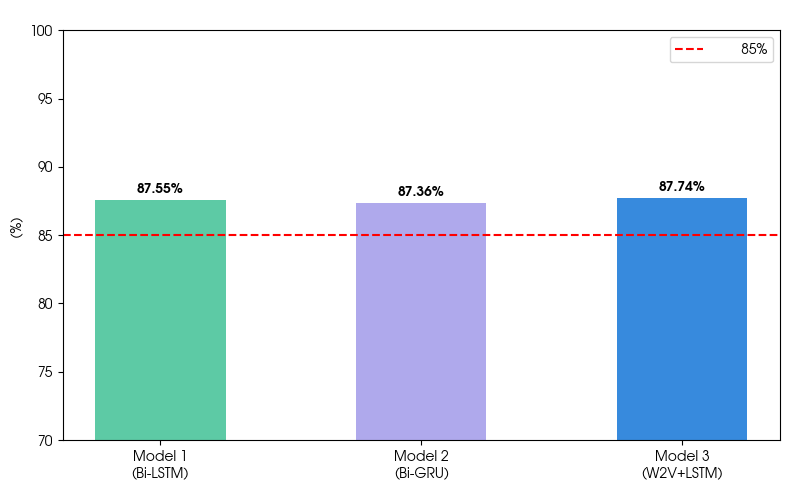


=== 최종 결과 요약 ===
Model 1 (Bi-LSTM): 87.55% 달성
Model 2 (Bi-GRU): 87.36% 달성
Model 3 (W2V+LSTM): 87.74% 달성


In [25]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = "URW Gothic"  # 한글 폰트
matplotlib.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

# 세 모델의 테스트 정확도를 딕셔너리로 정리
results = {
    'Model 1\n(Bi-LSTM)' : acc1 * 100,
    'Model 2\n(Bi-GRU)'  : acc2 * 100,
    'Model 3\n(W2V+LSTM)': acc3 * 100,
}

fig, ax = plt.subplots(figsize=(8, 5))

# 각 모델을 색상으로 구분하여 막대 그래프 생성
bars = ax.bar(
    results.keys(), results.values(),
    color=['#5DCAA5', '#AFA9EC', '#378ADD'],
    width=0.5
)

# 목표 정확도 85% 기준선 표시
ax.axhline(y=85, color='red', linestyle='--', linewidth=1.5, label='목표 정확도 85%')
ax.set_ylim(70, 100)  # y축 범위: 70~100% (차이를 잘 보이게)
ax.set_ylabel('정확도 (%)')
ax.set_title('네이버 영화 리뷰 감성분석 모델 비교')
ax.legend()

# 각 막대 위에 정확도 수치 표시
for bar, val in zip(bars, results.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x 위치: 막대 중앙
        bar.get_height() + 0.3,              # y 위치: 막대 위 살짝
        f'{val:.2f}%',
        ha='center', va='bottom', fontweight='bold'
    )

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)  # 이미지 파일로 저장
plt.show()

# 85% 달성 여부 최종 출력
print("\n=== 최종 결과 요약 ===")
for name, acc in results.items():
    status = "달성" if acc >= 85 else "미달성"
    print(f"{name.replace(chr(10), ' ')}: {acc:.2f}% {status}")

### 회고
1. 개인사유 휴가로 깊이있게 학습을 할 수 없었으나 기본적으로 노드 학습을 따라하면서 늦게나마 학습을 완료하였음.
2. 세모델 모두 목표 정확도 80% 이상을 초과 달성한 것을 확인할 수 있었고 최고-최저 간 성능차이도 0.38%로 매우 근소한 수치를 확인하였음.
3. 학습모델별 비교분석
   1) Model1 Bi-LSTM : 양방향 LSTM은 문장을 순방향과 역방향으로 동시에 읽어 앞뒤 문맥을 모두 반영함. 영화 리뷰처럼 문장 끝부분에 감정이 집중되는 경우 역방향 학습이 효과적으로 작동한 것으로 보여짐
   2) Model2 Bi-GRU : LSTM보다 파라미터 수가 적고 구조가 단순하지만 Model1과 거의 동등한 성능을 보였음. 학습 속도는 더 빠르면서 성능 차이는 0.19% 포인트에 불과하여, 리소스 효율 면에서는 GRU가 더 유리한 선택일 수 있음
   3) Model3 W2V+LSTM : 세 모델 중 가장 높은 성능을 기록하였음. 자체 학습한 W2V 임베딩을 초기값으로 사용함으로써 랜덤 초기화보다 더 의미 있는 단어 표현에서 학습을 시작한 것이 성능 향상에 기여한 것으로 판단됨. 특히 영화 리뷰 도메인 corpus로 학습한 임베딩이므로 도메인 특화 어휘(배우 이름, 영화 용어 등)를 잘 반영했을 가능성이 높음
4. 시간이 없는 관계로 향후 4가지 개선 방향에 대한 내용은 가용 시간에 추가적으로 확인해볼 예정
   1) vocab_size 조정: 현재 8000에서 16000으로 늘려 더 세밀한 서브워드 분할 시도
   2) 사전학습 임베딩 적용: fastText 한국어 벡터(cc.ko.300.vec) 로드 시 추가 성능 향상 기대
   3) Attention 메커니즘 추가: 감정에 중요한 단어에 가중치를 부여하여 분류 정확도 향상
   4) 모델 앙상블: 세 모델의 예측값을 평균내면 단일 모델보다 안정적인 성능 기대